<a href="https://colab.research.google.com/github/devanaraj07-glitch/DBA/blob/main/SQL_in_R_and_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading libraries

In [1]:
install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [8]:
library(sqldf)
library(dplyr)
library(ggplot2)
library(DBI)
library(RSQLite)

Loading the files

In [3]:
orders <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
customers <- read.csv("customers.csv")
drivers <- read.csv("drivers.csv")
hubs <- read.csv("hubs.csv")
incidents <- read.csv("incidents.csv")
complaints <- read.csv("complaints.csv")

In [9]:
con <- dbConnect(SQLite(), ":memory:")

In [10]:
dbWriteTable(con, "test_customers", customers)

Dataset customers displayed:

In [4]:
head(customers)

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
2,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
3,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,,Active
4,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
5,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
6,C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


# USING CRUD OPERATIONS:

1. SELECT

In [11]:
dbGetQuery(con, "SELECT * FROM test_customers LIMIT 5")

customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


2. INSERT

In [13]:
dbExecute(con, "
INSERT INTO test_customers VALUES (
999,
35,
'Central',
'Premium',
'2025-01-01',
8.5,
75,
'Mobile',
'Active'
)
")

dbGetQuery(con, "
SELECT * FROM test_customers
WHERE customer_id = 999
")

[1] 1

customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
999,35,Central,Premium,2025-01-01,8.5,75,Mobile,Active
999,35,Central,Premium,2025-01-01,8.5,75,Mobile,Active


3. UPDATE

In [14]:
dbExecute(con, "
UPDATE test_customers
SET loyalty_score = 9.5
WHERE customer_id = 999
")

dbGetQuery(con, "
SELECT * FROM test_customers
WHERE customer_id = 999
")

[1] 2

customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
999,35,Central,Premium,2025-01-01,9.5,75,Mobile,Active
999,35,Central,Premium,2025-01-01,9.5,75,Mobile,Active


4. DELETE

In [15]:
dbExecute(con, "
DELETE FROM test_customers
WHERE customer_id = 999
")

dbGetQuery(con, "
SELECT * FROM test_customers
WHERE customer_id = 999
")

[1] 2

customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>


# Analytical SQL Queries

1. Delivery performance by hub

In [16]:
delay_by_hub <- sqldf("
SELECT
    hub_id,
    COUNT(*) AS total_deliveries,
    AVG(julianday(delivery_completed_at) - julianday(dispatch_time)) * 24 AS avg_delivery_time_hours,
    AVG(customer_rating_post_delivery) AS avg_rating
FROM deliveries
GROUP BY hub_id
ORDER BY avg_delivery_time_hours DESC
")

delay_by_hub

hub_id,total_deliveries,avg_delivery_time_hours,avg_rating
<chr>,<int>,<dbl>,<dbl>
H05,115,10.904134,3.669558
H04,127,10.330491,3.915476
H07,115,9.918554,3.881858
H08,128,9.819178,3.884560
H01,136,9.381701,3.840593
H06,104,9.379300,3.882136
H02,106,8.867072,3.950952
H03,119,7.656914,3.895862


2. Route overrides impact

In [17]:
override_analysis <- sqldf("
SELECT
    manual_route_override_count,
    AVG(julianday(delivery_completed_at) - julianday(dispatch_time)) * 24 AS avg_delivery_time,
    AVG(customer_rating_post_delivery) AS avg_rating
FROM deliveries
GROUP BY manual_route_override_count
ORDER BY manual_route_override_count
")

override_analysis

manual_route_override_count,avg_delivery_time,avg_rating
<int>,<dbl>,<dbl>
0,9.724361,3.900816
1,9.574851,3.884463
2,9.210273,3.824600
3,8.683364,3.668393
4,9.806178,3.865652
5,9.901161,3.378571
7,21.552264,4.010000


3. Incident severity effect

In [18]:
incident_delivery <- sqldf("
SELECT
    i.severity,
    COUNT(i.incident_id) AS incident_count,
    AVG(julianday(d.delivery_completed_at) - julianday(d.dispatch_time)) * 24 AS avg_delay_hours
FROM incidents i
JOIN deliveries d
ON i.delivery_id = d.delivery_id
GROUP BY i.severity
")

incident_delivery

severity,incident_count,avg_delay_hours
<chr>,<int>,<dbl>
Critical,27,9.916962
High,68,9.963587
Low,79,6.711880
Medium,106,8.527367


4. Complaint analysis

In [19]:
complaint_analysis <- sqldf("
SELECT
    c.customer_type,
    COUNT(comp.complaint_id) AS complaint_count,
    AVG(comp.resolution_days) AS avg_resolution_time,
    AVG(d.customer_rating_post_delivery) AS avg_rating
FROM customers c
JOIN complaints comp
ON c.customer_id = comp.customer_id
JOIN deliveries d
ON comp.order_id = d.order_id
GROUP BY c.customer_type
")

complaint_analysis

customer_type,complaint_count,avg_resolution_time,avg_rating
<chr>,<int>,<dbl>,<dbl>
Consumer,176,7.744318,4.023621
Enterprise,18,8.666667,3.762941
SME,38,8.368421,3.515526


# Visualisations

1. Delivery performance by hub

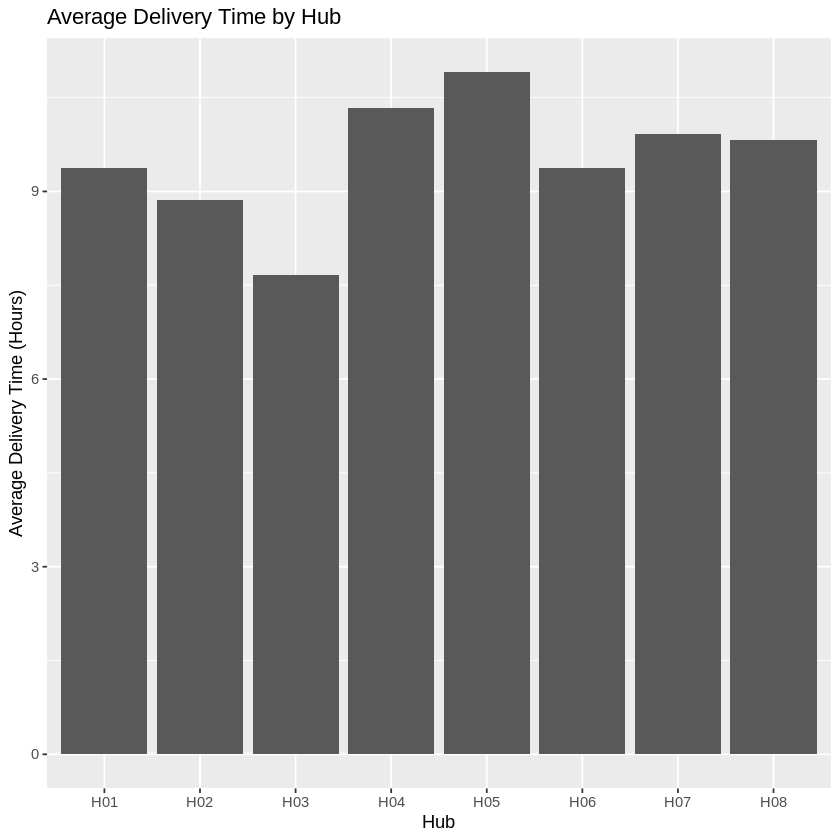

In [21]:
ggplot(delay_by_hub, aes(x = hub_id, y = avg_delivery_time_hours)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Delivery Time by Hub",
    x = "Hub",
    y = "Average Delivery Time (Hours)"
  )

2. Route override impact

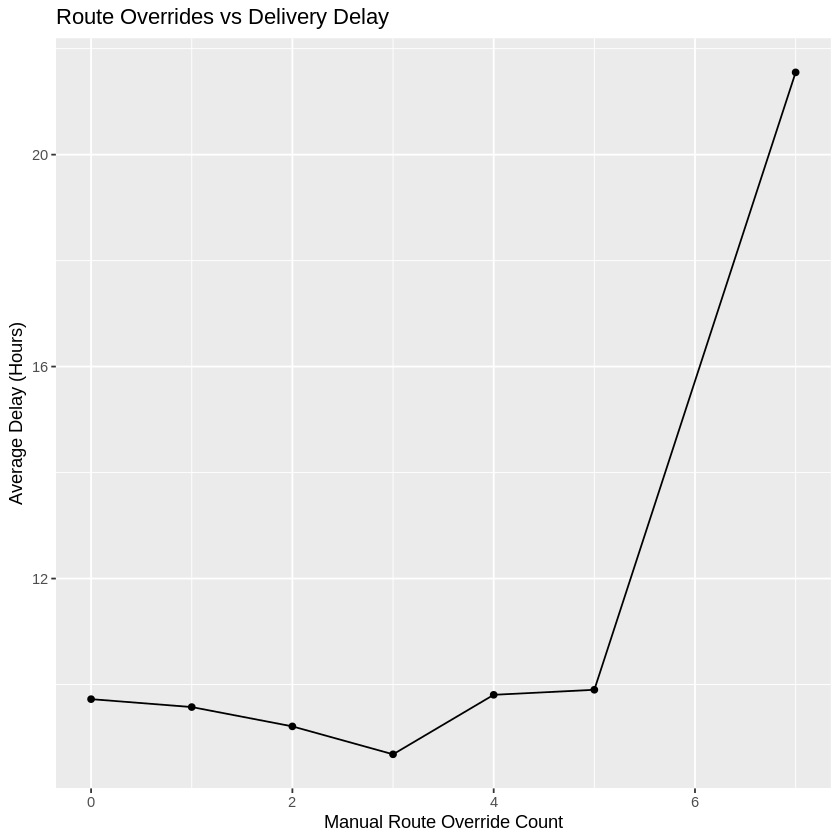

In [26]:
ggplot(override_analysis, aes(x = manual_route_override_count, y = avg_delivery_time)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Route Overrides vs Delivery Delay",
    x = "Manual Route Override Count",
    y = "Average Delay (Hours)"
  )

3. Incident frequency

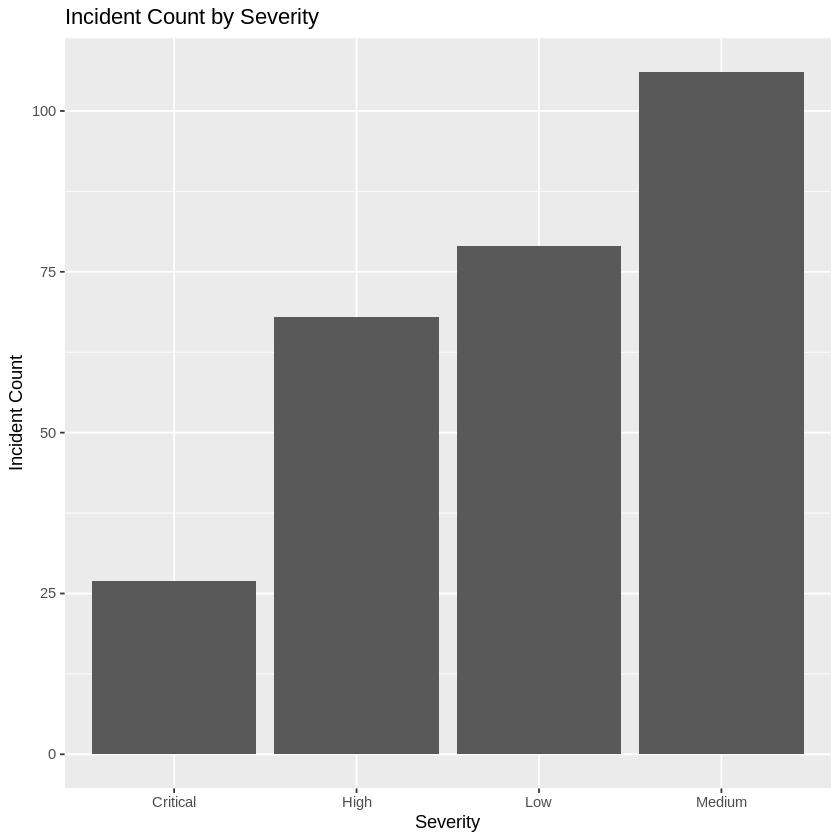

In [23]:
ggplot(incident_delivery, aes(x = severity, y = incident_count)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Incident Count by Severity",
    x = "Severity",
    y = "Incident Count"
  )

4. Complaint resolution time

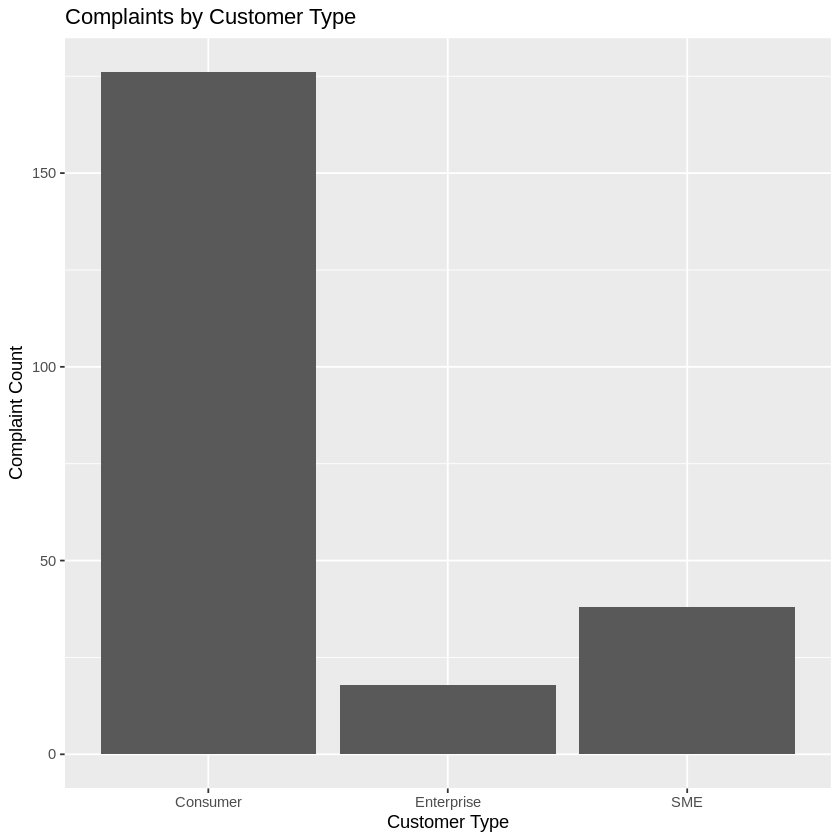

In [28]:
ggplot(complaint_analysis, aes(x = customer_type, y = complaint_count)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaints by Customer Type",
    x = "Customer Type",
    y = "Complaint Count"
  )